## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

print('Libraries loaded ')

Libraries loaded 


## 2. Load Data

In [2]:
import os
print(os.listdir('/kaggle/input'))

['competitions']


In [3]:
dataset_path = "/kaggle/input/competitions"
print(os.listdir(dataset_path))

['nlp-getting-started']


In [4]:
import os
dataset_path = "/kaggle/input/competitions/nlp-getting-started"
print(os.listdir(dataset_path))

['sample_submission.csv', 'train.csv', 'test.csv']


In [5]:
train = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/test.csv')
sub   = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/sample_submission.csv')

print(f'Train: {train.shape} | Test: {test.shape}')
train.head()

Train: (7613, 5) | Test: (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## 3. Exploratory Data Analysis

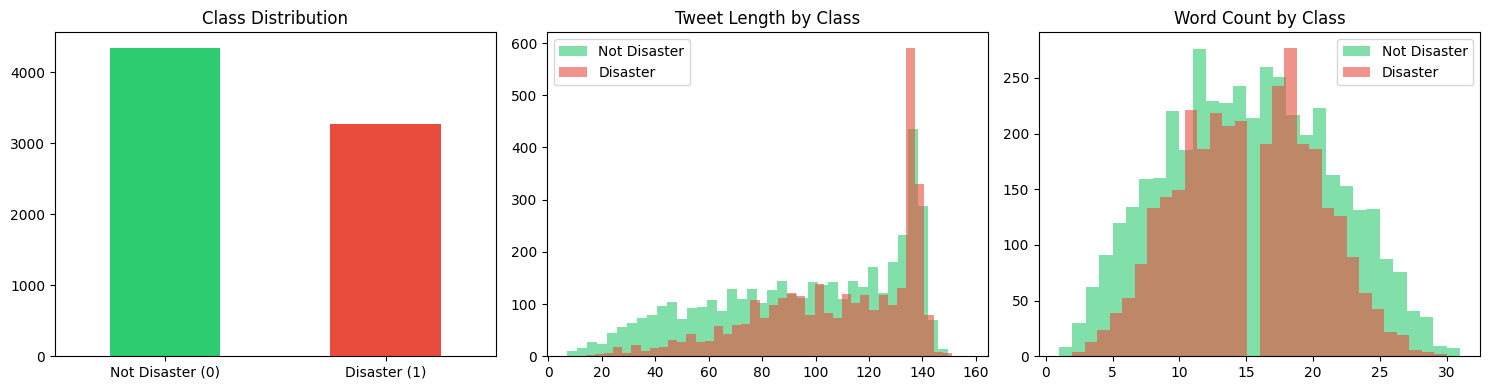


Missing values:
id               0
keyword         61
location      2533
text             0
target           0
text_len         0
word_count       0
dtype: int64


In [6]:
# Target distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class balance
train['target'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Not Disaster (0)', 'Disaster (1)'], rotation=0)
axes[0].set_xlabel('')

# Tweet length distribution
train['text_len'] = train['text'].str.len()
test['text_len']  = test['text'].str.len()
axes[1].hist(train[train['target']==0]['text_len'], bins=40, alpha=0.6, color='#2ecc71', label='Not Disaster')
axes[1].hist(train[train['target']==1]['text_len'], bins=40, alpha=0.6, color='#e74c3c', label='Disaster')
axes[1].set_title('Tweet Length by Class')
axes[1].legend()

# Word count
train['word_count'] = train['text'].str.split().str.len()
axes[2].hist(train[train['target']==0]['word_count'], bins=30, alpha=0.6, color='#2ecc71', label='Not Disaster')
axes[2].hist(train[train['target']==1]['word_count'], bins=30, alpha=0.6, color='#e74c3c', label='Disaster')
axes[2].set_title('Word Count by Class')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'\nMissing values:\n{train.isnull().sum()}')

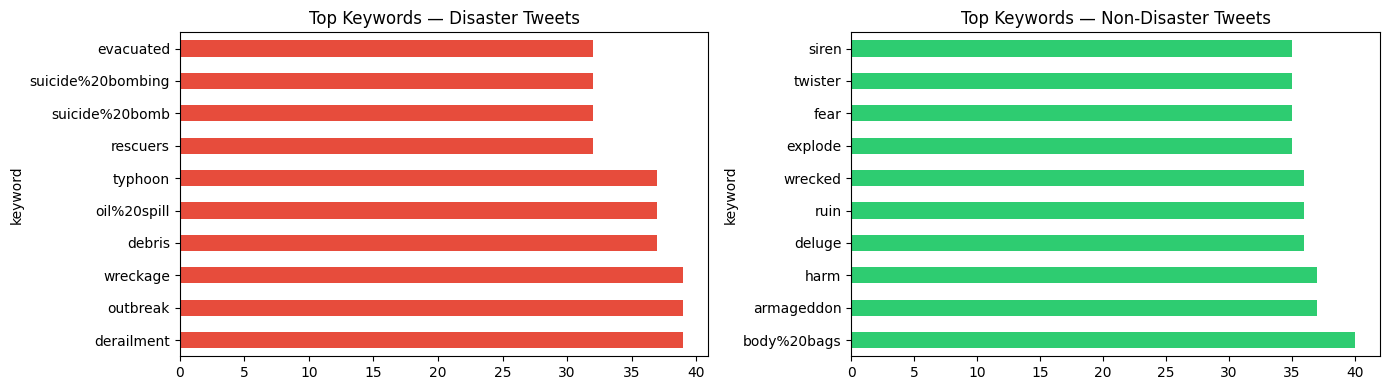

In [7]:
# Top keywords for disaster vs non-disaster
top_disaster_kw = (
    train[train['target']==1]['keyword']
    .dropna().value_counts().head(10)
)
top_nondisaster_kw = (
    train[train['target']==0]['keyword']
    .dropna().value_counts().head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
top_disaster_kw.plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('Top Keywords — Disaster Tweets')
top_nondisaster_kw.plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Top Keywords — Non-Disaster Tweets')
plt.tight_layout()
plt.show()

## 4. Text Preprocessing

In [8]:
def clean_text(text):
    """Clean tweet text for NLP."""
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove HTML entities
    text = re.sub(r'&amp;|&lt;|&gt;', '', text)
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # Keep hashtag words (remove #)
    text = re.sub(r'#(\w+)', r'\1', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
train['clean_text'] = train['text'].apply(clean_text)
test['clean_text']  = test['text'].apply(clean_text)

# Fill missing keyword with empty string
train['keyword'] = train['keyword'].fillna('').str.replace('%20', ' ')
test['keyword']  = test['keyword'].fillna('').str.replace('%20', ' ')

# Combine keyword + clean text for richer input
train['input_text'] = train['keyword'] + ' ' + train['clean_text']
test['input_text']  = test['keyword']  + ' ' + test['clean_text']

print('Example cleaned tweet:')
print('Original :', train['text'].iloc[0])
print('Cleaned  :', train['clean_text'].iloc[0])

Example cleaned tweet:
Original : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Cleaned  : our deeds are the reason of this earthquake may allah forgive us all


## 5. Feature Engineering

In [9]:
def add_features(df):
    """Add handcrafted NLP features."""
    df = df.copy()
    df['char_count']       = df['text'].str.len()
    df['word_count']       = df['text'].str.split().str.len()
    df['unique_words']     = df['text'].apply(lambda x: len(set(str(x).lower().split())))
    df['has_url']          = df['text'].str.contains(r'http|www', regex=True).astype(int)
    df['has_hashtag']      = df['text'].str.contains('#').astype(int)
    df['hashtag_count']    = df['text'].str.count('#')
    df['has_mention']      = df['text'].str.contains('@').astype(int)
    df['exclamation_count']= df['text'].str.count('!')
    df['question_count']   = df['text'].str.count(r'\?')
    df['capital_ratio']    = df['text'].apply(
        lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
    )
    df['has_keyword']      = (df['keyword'] != '').astype(int)
    return df

train = add_features(train)
test  = add_features(test)

META_FEATURES = ['char_count','word_count','unique_words','has_url',
                 'has_hashtag','hashtag_count','has_mention',
                 'exclamation_count','question_count','capital_ratio','has_keyword']

print('Meta features added ')
train[META_FEATURES].describe()

Meta features added 


,char_count,word_count,unique_words,has_url,has_hashtag,hashtag_count,has_mention,exclamation_count,question_count,capital_ratio,has_keyword
count,7613.000000,7613.000000,7613.000000,7613.000000,7613.000000,7613.000000,7613.000000,7613.000000,7613.000000,7613.000000,7613.000000
mean,101.037436,14.903586,14.246158,0.522265,0.231315,0.446999,0.267831,0.154079,0.410613,0.099661,0.991987
std,33.781325,5.732604,5.221835,0.499537,0.421701,1.099841,0.442858,0.619387,1.833392,0.107443,0.089160
min,7.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,78.000000,11.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.038462,1.000000
50%,107.000000,15.000000,14.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.074627,1.000000
75%,133.000000,19.000000,18.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.125926,1.000000
max,157.000000,31.000000,29.000000,1.000000,1.000000,13.000000,1.000000,12.000000,54.000000,1.000000,1.000000


## 6. Baseline — TF-IDF + Logistic Regression

In [10]:


import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Dataset class ──────────────────────────────────────────
class TweetDataset(Dataset):
    def __init__(self, texts, labels=None, max_len=128):
        self.encodings = tokenizer(
            list(texts), padding=True, truncation=True,
            max_length=max_len, return_tensors='pt'
        )
        self.labels = labels

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# ── Training helpers ───────────────────────────────────────
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def predict(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            preds.extend(outputs.logits.argmax(-1).cpu().numpy())
    return np.array(preds)

# ── 5-Fold CV + OOF predictions ───────────────────────────
X_texts = train['input_text'].values   # keyword + cleaned text from earlier
y_labels = train['target'].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds   = np.zeros(len(train), dtype=int)
test_preds  = np.zeros(len(test))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_texts, y_labels)):
    print(f'\n── Fold {fold+1}/5 ──')

    tr_ds  = TweetDataset(X_texts[tr_idx], y_labels[tr_idx])
    val_ds = TweetDataset(X_texts[val_idx], y_labels[val_idx])
    te_ds  = TweetDataset(test['input_text'].values)

    tr_loader  = DataLoader(tr_ds,  batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=64)
    te_loader  = DataLoader(te_ds,  batch_size=64)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    ).to(DEVICE)

    optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
    total_steps = len(tr_loader) * 4          # 4 epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=total_steps // 10,
        num_training_steps=total_steps
    )

    best_f1, best_preds = 0, None
    for epoch in range(4):
        loss = train_epoch(model, tr_loader, optimizer, scheduler)
        val_pred = predict(model, val_loader)
        f1 = f1_score(y_labels[val_idx], val_pred)
        print(f'  Epoch {epoch+1} | loss={loss:.4f} | val F1={f1:.4f}')
        if f1 > best_f1:
            best_f1 = f1
            best_preds = val_pred
            best_test  = predict(model, te_loader)

    oof_preds[val_idx] = best_preds
    test_preds += best_test / skf.n_splits
    print(f'  Best fold F1: {best_f1:.4f}')

print(f'\n Overall OOF F1: {f1_score(y_labels, oof_preds):.4f}')



config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Using device: cuda

── Fold 1/5 ──


...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1 | loss=0.4916 | val F1=0.7928
  Epoch 2 | loss=0.3529 | val F1=0.8050
  Epoch 3 | loss=0.2890 | val F1=0.8023
  Epoch 4 | loss=0.2430 | val F1=0.8003
  Best fold F1: 0.8050

── Fold 5/5 ──


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1 | loss=0.5048 | val F1=0.7886
  Epoch 2 | loss=0.3525 | val F1=0.7991
  Epoch 3 | loss=0.2885 | val F1=0.7962
  Epoch 4 | loss=0.2409 | val F1=0.7994
  Best fold F1: 0.7994

 Overall OOF F1: 0.8026


In [11]:
# ── Submission ─────────────────────────────────────────────
submission = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/sample_submission.csv')
submission['target'] = (test_preds >= 0.5).astype(int)
submission.to_csv('submission.csv', index=False)
print('Submission saved ')

Submission saved 
